In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

In [3]:
# Dataset Load

df = pd.read_csv(r"C:\Users\HP\Desktop\NEW PROJECTS CLASS\ML Project\Student_Placement_Prediction\data\placement_dataset.csv")
df.head()

,CGPA,Internship,Projects,AptitudeScore,CommunicationScore,Placed,PackageLPA
0,6.87,1,3,70,54,1,3.60
1,9.75,2,6,63,73,1,9.11
2,8.66,0,6,74,81,1,4.91
3,7.99,0,3,83,94,1,3.34
4,5.78,0,7,99,83,1,2.89


In [5]:
# Dataset Info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CGPA                500 non-null    float64
 1   Internship          500 non-null    int64  
 2   Projects            500 non-null    int64  
 3   AptitudeScore       500 non-null    int64  
 4   CommunicationScore  500 non-null    int64  
 5   Placed              500 non-null    int64  
 6   PackageLPA          500 non-null    float64
dtypes: float64(2), int64(5)
memory usage: 27.5 KB


In [6]:
# Missing Values Check

df.isnull().sum()

CGPA                  0
Internship            0
Projects              0
AptitudeScore         0
CommunicationScore    0
Placed                0
PackageLPA            0
dtype: int64

In [7]:
# Statistics

df.describe()

,CGPA,Internship,Projects,AptitudeScore,CommunicationScore,Placed,PackageLPA
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,7.492900,1.386000,3.984000,70.120000,69.178000,0.820000,4.664020
std,1.493406,1.089669,2.037658,17.176486,17.554562,0.384572,1.816445
min,5.030000,0.000000,1.000000,40.000000,40.000000,0.000000,2.500000
25%,6.207500,0.000000,2.000000,55.000000,53.000000,1.000000,2.960000
50%,7.565000,1.000000,4.000000,70.500000,69.000000,1.000000,4.540000
75%,8.782500,2.000000,6.000000,85.000000,85.000000,1.000000,6.122500
max,9.960000,3.000000,7.000000,99.000000,99.000000,1.000000,9.240000


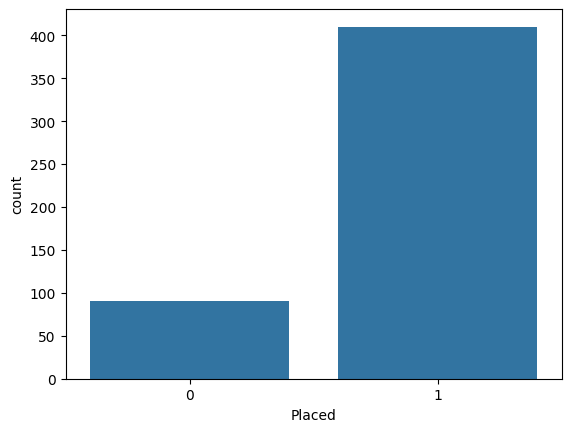

In [8]:
# Placement Count

sns.countplot(x='Placed', data=df)
plt.show()

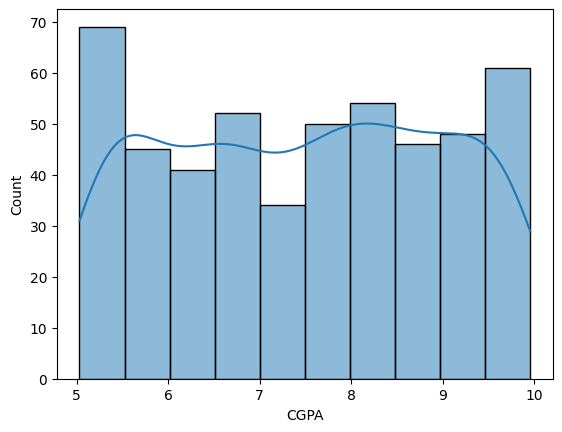

In [9]:
# CGPA Distribution

sns.histplot(df['CGPA'], kde=True)
plt.show()

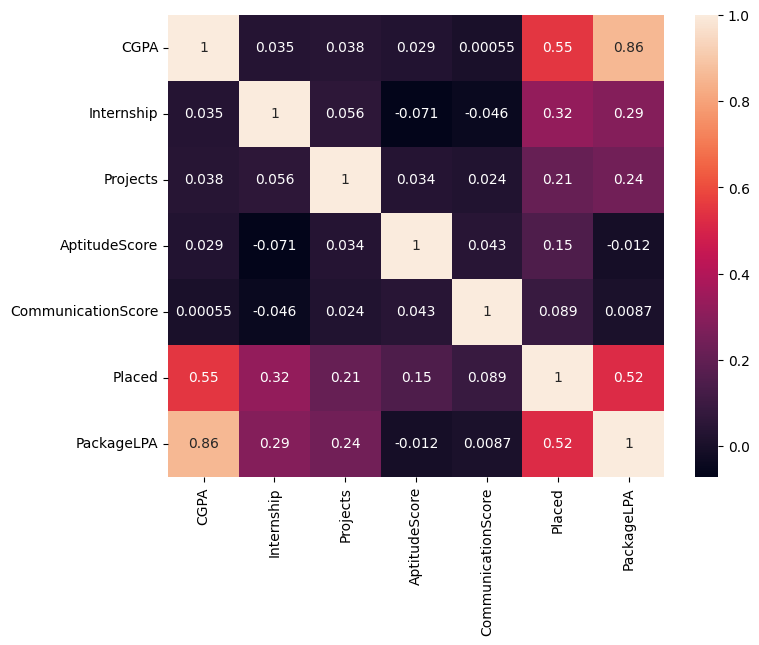

In [10]:
# Correlation Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [11]:
# Features and Target

X = df[['CGPA',
        'Internship',
        'Projects',
        'AptitudeScore',
        'CommunicationScore']]

y = df['Placed']

In [12]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
# Train Model

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [14]:
# Prediction

y_pred = model.predict(X_test)

In [15]:
# Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.96


In [17]:
# Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.88      0.91        24
           1       0.96      0.99      0.97        76

    accuracy                           0.96       100
   macro avg       0.96      0.93      0.94       100
weighted avg       0.96      0.96      0.96       100



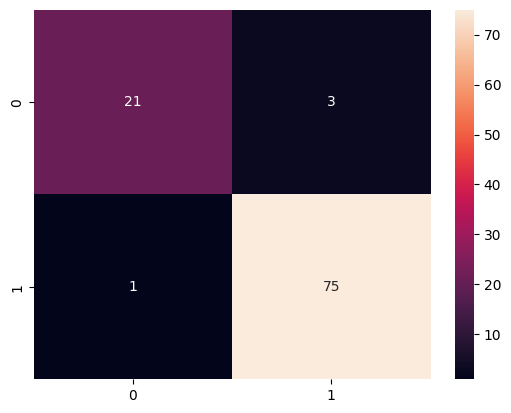

In [18]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [19]:
# Models Folder Create

import os

os.makedirs("models", exist_ok=True)

print("Models folder created")

Models folder created


In [20]:
# Save Model

joblib.dump(model, "models/placement_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [21]:
# Check Model Exists

import os

print(os.path.exists("models/placement_model.pkl"))
print(os.path.getsize("models/placement_model.pkl"))

True
1231


In [22]:
# Test Loading Model

loaded_model = joblib.load("models/placement_model.pkl")

print("OK")

OK


In [23]:
print(os.getcwd())

c:\Users\HP\Desktop\NEW PROJECTS CLASS\ML Project\Student_Placement_Prediction\notebooks


In [24]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(model, "../models/placement_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [25]:
import os

print(os.path.exists("../models/placement_model.pkl"))

True
